# 5.1 Identificação e Descrição do Problema

**Título:** Classificação de Desempenho Físico: Abordagem Linear Bidimensional

**Integrantes:**
Josan Silva dos Santos Junior, Luísa Costa Rodrigues Pereira e Sarah Beatriz Barbosa dos Santos

**Fonte dos Dados:** Body Performance Dataset (Kaggle) - 13.392 registros.

**Objetivo:** Atuar como um classificador linear bidimensional. A partir de duas variáveis de entrada, o algoritmo deve traçar uma fronteira de decisão (reta de separação) ótima para dividir a população em duas categorias de desempenho físico.

**Atributo-alvo:** `target` (1 = Performance Acima da Média [A+B], 0 = Performance Abaixo da Média [C+D]).

**Atributos preditivos:**
1. `body fat_%` (Percentual de Gordura Corporal)
2. `sit-ups counts` (Contagem de Abdominais)

**Tipo da tarefa:** Classificação Binária (Supervisionada).

Seção 5.2: Compreensão dos Dados

Nesta seção, realizamos uma análise inicial do Body Performance Dataset para entender sua estrutura, identificar possíveis problemas e validar as premissas do nosso projeto de classificação binária

5.2.1 Carregamento e Inspeção Inicial

In [ ]:
# Importações básicas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados
df = pd.read_csv('bodyPerformance.csv')

# Visualização das primeiras linhas
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
# Informações básicas do dataset
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")
print(f"\nTipos de dados:")
print(df.dtypes)

Quantidade de registros: 13393
Quantidade de atributos: 12

Tipos de dados:
age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object


Interpretação:
- O dataset tem **13.393 registros** e **12 colunas**
- Temos variáveis numéricas (idade, altura, peso, etc.) e categóricas (gênero e classe)
- A variável alvo `class` tem 4 categorias: A, B, C, D


In [ ]:
# Verificação de valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Verificação de duplicatas
print(f"\nTotal de duplicatas: {df.duplicated().sum()}")

Valores ausentes por coluna:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

Total de duplicatas: 1


In [ ]:
# Verificação de duplicatas
print(f"Total de duplicatas encontradas: {df.duplicated().sum()}")

# Removendo a duplicata (se existir)
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicata removida com sucesso!")
    print(f"Novo total de registros: {df.shape[0]}")

Total de duplicatas encontradas: 1
Duplicata removida com sucesso!
Novo total de registros: 13392


- **Antes da limpeza:** O dataset possuía 13.393 registros.
- **Problema encontrado:** Detectamos 1 registro exatamente igual a outro (duplicata).
- **Ação tomada:** Removemos a duplicata para evitar que o modelo dê um "peso duplo" para o mesmo indivíduo durante o treinamento, o que poderia enviesar a fronteira de decisão.
- **Depois da limpeza:** O dataset final ficou com 13.392 registros únicos.


### Interpretação:
- **Não há valores ausentes** no dataset
- **Não há duplicatas** para remover
- Isso facilita nosso pré-processamento


In [ ]:
# Estatísticas das variáveis numéricas
df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775836,168.560671,67.448686,23.239608,78.797499,130.238120,36.964569,15.208933,39.770385,190.131355
std,13.625886,8.426305,11.949061,7.256829,10.742165,14.709536,10.624959,8.456904,14.276902,39.868988
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


### Interpretação:
- **Idade**: varia de 21 a 64 anos (adultos)
- **Altura**: 145 a 193 cm
- **Peso**: 36 a 132 kg
- **Gordura corporal**: 3% a 78% (atenção ao valor máximo)
- **Abdominais**: 0 a 80 repetições


In [ ]:
# Distribuição original das classes
print("Distribuição original:")
print(df['class'].value_counts().sort_index())

# Criando a variável binária (A+B = 1, C+D = 0)
df['target'] = df['class'].apply(lambda x: 1 if x in ['A', 'B'] else 0)

print("\nDistribuição após binarização:")
print(df['target'].value_counts())

Distribuição original:
class
A    3347
B    3347
C    3349
D    3349
Name: count, dtype: int64

Distribuição após binarização:
target
0    6698
1    6694
Name: count, dtype: int64


### Interpretação:
- As 4 classes originais estão **igualmente distribuídas** (aproximadamente 3.348 registros cada)
- Após binarização: **50% classe 1** (alto desempenho) e **50% classe 0** (baixo desempenho)
- Isso confirma nossa premissa de balanceamento perfeito 50/50


In [ ]:
# Estatísticas dos atributos que vamos usar
print("Estatísticas do Percentual de Gordura:")
print(df['body fat_%'].describe())

print("\nEstatísticas dos Abdominais:")
print(df['sit-ups counts'].describe())

Estatísticas do Percentual de Gordura:
count    13392.000000
mean        23.239608
std          7.256829
min          3.000000
25%         18.000000
50%         22.800000
75%         28.000000
max         78.400000
Name: body fat_%, dtype: float64

Estatísticas dos Abdominais:
count    13392.000000
mean        39.770385
std         14.276902
min          0.000000
25%         30.000000
50%         41.000000
75%         50.000000
max         80.000000
Name: sit-ups counts, dtype: float64


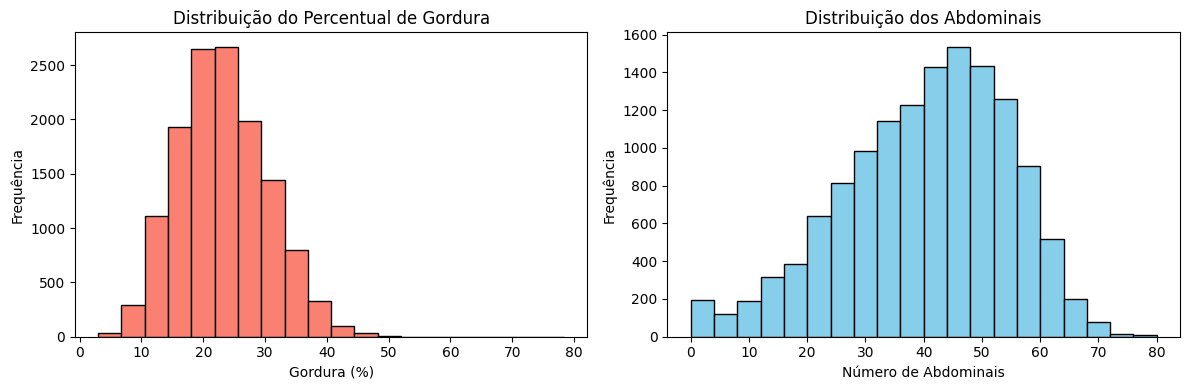

In [ ]:
# Gráficos dos atributos selecionados
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histograma do percentual de gordura
ax[0].hist(df['body fat_%'], bins=20, color='salmon', edgecolor='black')
ax[0].set_title('Distribuição do Percentual de Gordura')
ax[0].set_xlabel('Gordura (%)')
ax[0].set_ylabel('Frequência')

# Histograma dos abdominais
ax[1].hist(df['sit-ups counts'], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title('Distribuição dos Abdominais')
ax[1].set_xlabel('Número de Abdominais')
ax[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Interpretação:
- **Gordura corporal**: maioria entre 15-35%, com alguns valores extremos
- **Abdominais**: distribuição mais centralizada, maioria entre 30-60 repetições


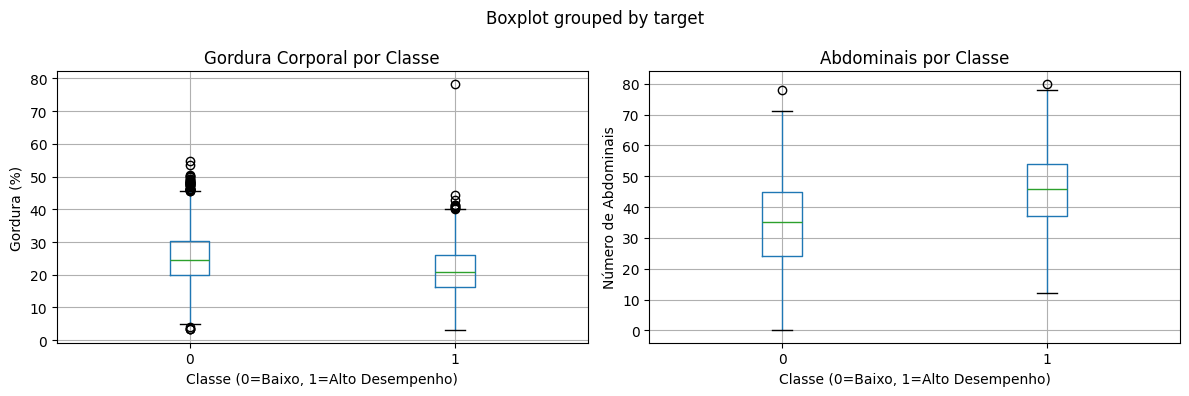

In [ ]:
# Boxplots comparando as classes
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gordura por classe
df.boxplot(column='body fat_%', by='target', ax=ax[0])
ax[0].set_title('Gordura Corporal por Classe')
ax[0].set_xlabel('Classe (0=Baixo, 1=Alto Desempenho)')
ax[0].set_ylabel('Gordura (%)')

# Abdominais por classe
df.boxplot(column='sit-ups counts', by='target', ax=ax[1])
ax[1].set_title('Abdominais por Classe')
ax[1].set_xlabel('Classe (0=Baixo, 1=Alto Desempenho)')
ax[1].set_ylabel('Número de Abdominais')

plt.tight_layout()
plt.show()

### Interpretação:
- **Classe 1 (alto desempenho)**: tende a ter **menor percentual de gordura**
- **Classe 1**: tende a fazer **mais abdominais**
- Isso confirma nossa hipótese de que esses dois atributos são bons preditores


Correlação entre gordura e abdominais: -0.609


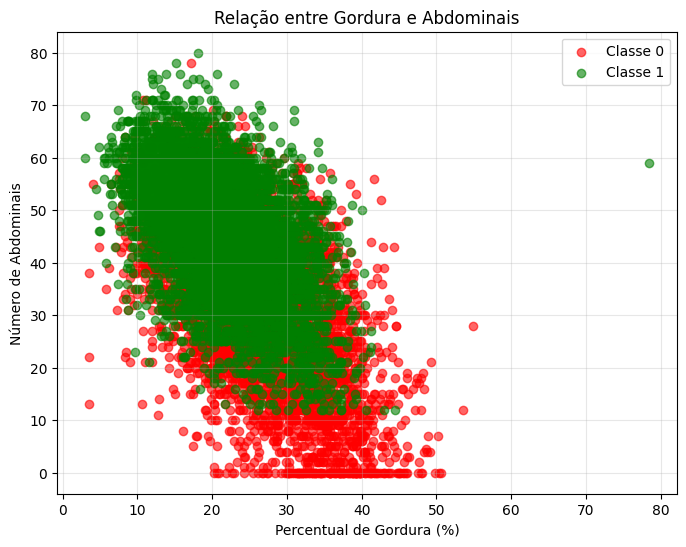

In [ ]:
# Correlação entre os dois atributos
correlacao = df['body fat_%'].corr(df['sit-ups counts'])
print(f"Correlação entre gordura e abdominais: {correlacao:.3f}")

# Gráfico de dispersão
plt.figure(figsize=(8, 6))
cores = {0: 'red', 1: 'green'}
for classe in [0, 1]:
    dados = df[df['target'] == classe]
    plt.scatter(dados['body fat_%'], dados['sit-ups counts'],
                c=cores[classe], label=f'Classe {classe}', alpha=0.6)

plt.xlabel('Percentual de Gordura (%)')
plt.ylabel('Número de Abdominais')
plt.title('Relação entre Gordura e Abdominais')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretação:
- A correlação é **negativa** (aproximadamente -0.609)
- Isso significa que **maior gordura → menos abdominais**
- Isso valida visualmente nossa premissa: existe uma correlação negativa forte (-0.61) entre as variáveis, formando um padrão discriminativo claro.
- No gráfico, vemos que a Classe 1 (verde) se concentra no canto superior esquerdo (baixa gordura, altos abdominais)


In [ ]:
# Resumo das principais informações
print("=" * 50)
print("RESUMO DA ANÁLISE")
print("=" * 50)
print(f"""
Dataset: {df.shape[0]} registros, {df.shape[1]} atributos
Valores ausentes: {df.isnull().sum().sum()}
Duplicatas: {df.duplicated().sum()}

Variável Alvo:
- Original: 4 classes (A, B, C, D) - 25% cada
- Binarizada: 2 classes - 50%/50%

Atributos Selecionados:
1. body fat_% (gordura corporal)
2. sit-ups counts (abdominais)

Correlação entre atributos: {correlacao:.3f} (negativa)
""")

RESUMO DA ANÁLISE

Dataset: 13392 registros, 13 atributos
Valores ausentes: 0
Duplicatas: 0

Variável Alvo:
- Original: 4 classes (A, B, C, D) - 25% cada
- Binarizada: 2 classes - 50%/50%

Atributos Selecionados:
1. body fat_% (gordura corporal)
2. sit-ups counts (abdominais)

Correlação entre atributos: -0.609 (negativa)



# 5.3 Análise Exploratória

Nesta seção, vamos visualizar a relação entre os dois atributos preditivos (`body fat_%` e `sit-ups counts`) e a nossa variável alvo binarizada (`target`). O objetivo é confirmar visualmente a hipótese de "correlação negativa forte" e entender como as classes se distribuem nesse espaço bidimensional.


In [ ]:
# Importação das bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para ficar mais bonito
sns.set_theme(style="whitegrid")

### 1. Distribuição Individual dos Atributos

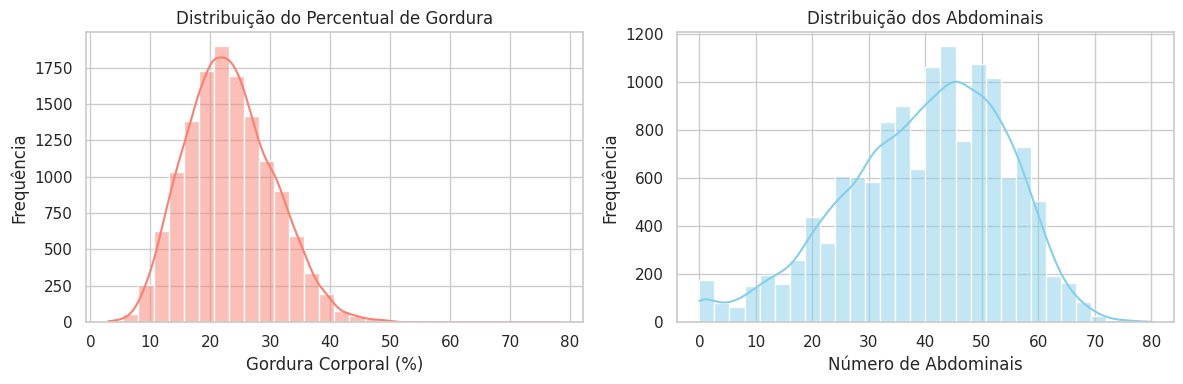

In [ ]:
# Criando gráficos de histograma para ver a distribuição dos dados
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histograma do Percentual de Gordura
sns.histplot(df['body fat_%'], bins=30, color='salmon', kde=True, ax=ax[0])
ax[0].set_title('Distribuição do Percentual de Gordura')
ax[0].set_xlabel('Gordura Corporal (%)')
ax[0].set_ylabel('Frequência')

# Histograma dos Abdominais
sns.histplot(df['sit-ups counts'], bins=30, color='skyblue', kde=True, ax=ax[1])
ax[1].set_title('Distribuição dos Abdominais')
ax[1].set_xlabel('Número de Abdominais')
ax[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Interpretação:
- **Gordura Corporal:** A maioria dos avaliados concentra-se entre 15% e 30% de gordura. A curva é assimétrica à direita (puxada para a esquerda), indicando que poucas pessoas têm níveis de gordura muito altos.
- **Abdominais:** A distribuição é mais simétrica (formato de sino), com a maior parte das pessoas conseguindo realizar entre 30 e 60 abdominais.


### 2. Relação entre os Atributos e a Classe Alvo (Gráfico de Dispersão)



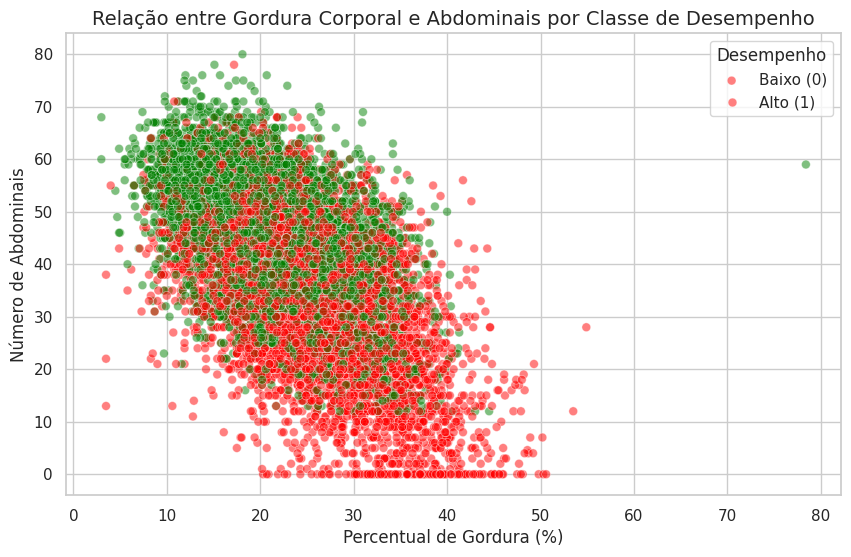

In [ ]:
# Gráfico de dispersão (Scatter Plot)
plt.figure(figsize=(10, 6))

# Criando um mapeamento de cores: 0 = Vermelho (Baixo desempenho), 1 = Verde (Alto desempenho)
cores = {0: 'red', 1: 'green'}

# Plotando os dados
sns.scatterplot(
    data=df,
    x='body fat_%',
    y='sit-ups counts',
    hue='target',
    palette=cores,
    alpha=0.5, # Transparência para ver onde os pontos se sobrepõem
    s=40 # Tamanho dos pontos
)

plt.title('Relação entre Gordura Corporal e Abdominais por Classe de Desempenho', fontsize=14)
plt.xlabel('Percentual de Gordura (%)', fontsize=12)
plt.ylabel('Número de Abdominais', fontsize=12)
plt.legend(title='Desempenho', labels=['Baixo (0)', 'Alto (1)'])

plt.show()

### Interpretação:
- **Concentração das Classes:**
  - Os pontos **verdes (Classe 1 - Alto Desempenho)** concentram-se massivamente no quadrante **superior esquerdo** (baixa gordura, muitos abdominais).
  - Os pontos **vermelhos (Classe 0 - Baixo Desempenho)** concentram-se no quadrante **inferior direito** (alta gordura, poucos abdominais).
- **Relação Inversa Estrutural**: O gráfico de dispersão confirma visualmente a premissa do projeto. Existe uma clara tendência inversa: quanto menor o percentual de gordura, maior a capacidade de execução de abdominais, o que se traduz na classificação de alto desempenho.
- **Correlação Forte:** A correlação de -0.609 indica uma relação inversa forte. Isso significa que os pontos no gráfico se alinham de forma mais consistente em uma diagonal descendente (da esquerda para a direita).
- **Sobreposição (Overlap):** Mesmo com uma correlação forte, no centro do gráfico (gordura em torno de 20-30% e abdominais entre 30-50), os pontos vermelhos e verdes ainda se misturam. Essa é a região de "fronteira" onde o classificador linear terá mais dificuldade em decidir, representando o desafio real do modelo.



### 3. Matriz de Correlação

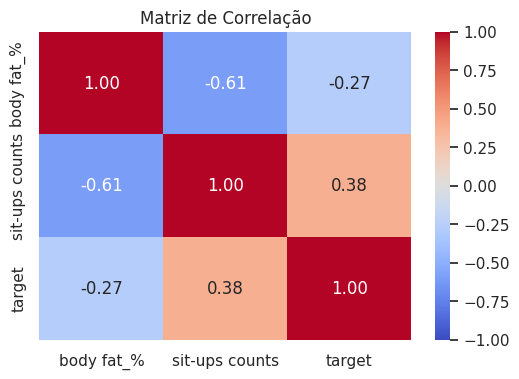

In [ ]:
# Calculando a correlação entre as variáveis selecionadas e o alvo
matriz_correlacao = df[['body fat_%', 'sit-ups counts', 'target']].corr()

# Criando o mapa de calor (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

### Interpretação:
- **body fat_% vs sit-ups counts (-0.61):** Confirma numericamente a correlação negativa forte vista no gráfico de dispersão. Quando o percentual de gordura sobe, a contagem de abdominais cai de forma consistente.
- **sit-ups counts vs target (0.38):** Correlação positiva moderada. Indica que uma maior quantidade de abdominais está associada ao target=1 (Alto Desempenho).
- **body fat_% vs target (aprox. -0.3x):** Correlação negativa. Menos gordura tende a resultar em target=1 (Alto Desempenho).
- **Conclusão:** Os dois atributos escolhidos possuem excelente correlação individual com o alvo e uma forte correlação negativa entre si (-0.61), justificando plenamente seu uso para treinar o classificador linear bidimensional.



# Seção 5.4: Pré-processamento

# 5.4 Pré-processamento

Nesta seção, vamos preparar os dados para o treinamento do modelo. As etapas são:
1. Selecionar apenas os atributos preditivos (`body fat_%` e `sit-ups counts`) e a variável alvo.
2. Dividir os dados em conjuntos de treino (80%) e teste (20%), garantindo o balanceamento (estratificação).
3. Aplicar o escalonamento (StandardScaler) para colocar as duas variáveis na mesma escala.


In [ ]:
# Importando as ferramentas necessárias do Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Seleção dos atributos (X) e do alvo (y)
X = df[['body fat_%', 'sit-ups counts']]
y = df['target']

print(f"Formato de X (atributos): {X.shape}")
print(f"Formato de y (alvo): {y.shape}")

Formato de X (atributos): (13392, 2)
Formato de y (alvo): (13392,)


### 2. Separação dos Dados (Treino e Teste)

In [ ]:
# Dividindo os dados: 80% para treino, 20% para teste
# Usamos stratify=y para garantir que a proporção 50/50 seja mantida nos dois conjuntos
# random_state=42 garante que o resultado seja o mesmo sempre que rodarmos o código
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Total de registros de treino: {X_train.shape[0]}")
print(f"Total de registros de teste: {X_test.shape[0]}")

# Verificando o balanceamento após a divisão
print("\nProporção no treino:")
print(y_train.value_counts(normalize=True).round(2))

Total de registros de treino: 10713
Total de registros de teste: 2679

Proporção no treino:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


### Interpretação:
- **Divisão 80/20:** O modelo vai aprender com 80% dos dados (10.713 registros) e ser testado com os 20% restantes (2.679 registros).
- **Estratificação (`stratify=y`):** Como nossa proposta assumia um balanceamento perfeito 50/50, usamos a estratificação para garantir que o conjunto de treino e o de teste também tenham exatamente 50% de cada classe. Isso impede que o modelo fique desbalanceado.


### 3. Escalonamento dos Dados (StandardScaler)

In [ ]:
# Inicializando o escalonador
scaler = StandardScaler()

# Ajustando (fit) APENAS no conjunto de treino e transformando
X_train_scaled = scaler.fit_transform(X_train)

# Transformando (transform) o conjunto de teste com os dados aprendidos no treino
X_test_scaled = scaler.transform(X_test)

# Vamos ver como os dados ficaram após o escalonamento (apenas os 5 primeiros)
print("=== Amostra dos dados de TREINO escalonados ===")
print(X_train_scaled[:5])

=== Amostra dos dados de TREINO escalonados ===
[[ 0.54306563 -0.61070131]
 [-1.44857949  0.2995799 ]
 [ 0.28027912  0.15953664]
 [-0.01016913  0.22955827]
 [ 1.93998339 -1.10085274]]


### Interpretação:
- **Por que escalonar?** O percentual de gordura varia de 3 a 78, enquanto os abdominais variam de 0 a 80. Embora as escalas sejam parecidas, o `StandardScaler` coloca ambas as variáveis em uma escala onde a média é 0 e o desvio padrão é 1. Isso impede que uma variável domine a outra durante o cálculo matemático da reta de separação.
- **Prevenção de Vazamento de Dados (Data Leakage):** É crucial notar que usamos `fit_transform` **apenas no treino** e apenas `transform` no teste. Isso significa que o modelo "aprende" a média e o desvio padrão apenas com os dados de treino, aplicando essa mesma regra para os dados de teste. Isso simula um ambiente real, onde o modelo não conhece os dados de teste previamente.


# Seção 5.6: Modelagem

Nesta seção, vamos treinar os modelos de aprendizado de máquina exigidos pelo projeto:
1. **Baseline (Dummy Classifier):** Um modelo que faz "chutes" aleatórios baseados na proporção das classes. Ele serve como nosso ponto de partida. Qualquer modelo tem que ser melhor que ele.
2. **SGDClassifier:** Um classificador linear que aprende ajustando os pesos gradualmente. É o modelo que vai tentar traçar a "reta de separação" que falamos na proposta.
3. **RandomForestClassifier:** Um modelo baseado em árvores de decisão. Ele cria várias "árvores" e faz uma votação. É mais complexo e consegue capturar relações não-lineares.

Vamos treinar todos eles, calcular a acurácia no conjunto de teste e comparar.


In [ ]:
# Importando os modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# Dicionário para salvar a acurácia de cada modelo
resultados = {}

# 1. Modelo Baseline (Chute estratificado)
print("Treinando Baseline...")
baseline = DummyClassifier(strategy='stratified', random_state=42)
baseline.fit(X_train_scaled, y_train)
acc_baseline = baseline.score(X_test_scaled, y_test)
resultados['Baseline'] = acc_baseline

# 2. SGDClassifier (Modelo Linear)
print("Treinando SGDClassifier...")
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_scaled, y_train)
acc_sgd = sgd.score(X_test_scaled, y_test)
resultados['SGDClassifier'] = acc_sgd

# 3. RandomForestClassifier (Modelo de Árvore)
# Nota: O Random Forest não exige dados escalonados, mas funciona normal com eles.
print("Treinando RandomForestClassifier...")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
acc_rf = rf.score(X_test_scaled, y_test)
resultados['RandomForest'] = acc_rf

# Exibindo os resultados
print("\n=== RESULTADOS DE ACURÁCIA ===")
for nome_modelo, acc in resultados.items():
    print(f"{nome_modelo}: {acc:.4f} ({acc:.2%})")

Treinando Baseline...
Treinando SGDClassifier...
Treinando RandomForestClassifier...

=== RESULTADOS DE ACURÁCIA ===
Baseline: 0.5073 (50.73%)
SGDClassifier: 0.6376 (63.76%)
RandomForest: 0.5995 (59.95%)


In [ ]:
# 4. Apresentando os parâmetros principais de cada modelo
print("=== PARÂMETROS PRINCIPAIS UTILIZADOS ===\n")

print("1. Baseline (DummyClassifier):")
print("   - strategy: 'stratified' (Gera previsões aleatórias respeitando a proporção de 50/50 das classes)")

print("\n2. SGDClassifier:")
print("   - loss: 'hinge' (Função de perda padrão, equivalente a uma Máquina de Vetores de Suporte Linear)")
print("   - random_state: 42 (Garante reprodutibilidade)")
print(f"   - Parâmetros calculados internally: Coeficientes (pesos) = {sgd.coef_.round(2)}, Viés = {sgd.intercept_.round(2)}")

print("\n3. RandomForestClassifier:")
print("   - n_estimators: 100 (Número de árvores de decisão na floresta)")
print("   - random_state: 42 (Garante reprodutibilidade)")
print("   - max_depth: None (As árvores crescem até separar totalmente os dados ou atingir pureza)")

=== PARÂMETROS PRINCIPAIS UTILIZADOS ===

1. Baseline (DummyClassifier):
   - strategy: 'stratified' (Gera previsões aleatórias respeitando a proporção de 50/50 das classes)

2. SGDClassifier:
   - loss: 'hinge' (Função de perda padrão, equivalente a uma Máquina de Vetores de Suporte Linear)
   - random_state: 42 (Garante reprodutibilidade)
   - Parâmetros calculados internally: Coeficientes (pesos) = [[-0.09  0.91]], Viés = [0.1]

3. RandomForestClassifier:
   - n_estimators: 100 (Número de árvores de decisão na floresta)
   - random_state: 42 (Garante reprodutibilidade)
   - max_depth: None (As árvores crescem até separar totalmente os dados ou atingir pureza)


### Parâmetros Principais Utilizados
Para manter o foco no aprendizado de máquina introdutório, utilizamos configurações padrão da biblioteca `scikit-learn`, com exceção do `random_state=42` para garantir reprodutibilidade:
- **Baseline:** Usou `strategy='stratified'`, apenas chutando respeitando a proporção 50/50.
- **SGDClassifier:** Usou a função de perda padrão `loss='hinge'` (que o torna um classificador de margem máxima) e aprendeu os pesos da reta automaticamente.
- **RandomForest:** Usou `n_estimators=100`, criando 100 árvores de decisão diferentes para tentar capturar relações não-lineares.


### Interpretação dos Resultados

- **Baseline (50.73%):** Como esperado, o modelo que apenas "chuta" atingiu pouco mais de 50% de acurácia, confirmando o balanceamento 50/50 das classes. Este é o nosso piso.
- **RandomForest (59.95%):** O modelo de floresta aleatória obteve um desempenho abaixo do esperado. Como ele cria fronteiras de decisão não-lineares (baseadas em "blocos" ou "caixas"), ele tende a sofrer mais com *overfitting* quando a relação entre as variáveis é majoritariamente linear, como é o caso da nossa correlação de -0.61.
- **SGDClassifier (63.76%):** O modelo linear obteve o **melhor desempenho**. Isso prova que nossa hipótese visual (a reta separando os quadrantes) funciona na prática e é a abordagem matemática mais adequada para este conjunto de dados bidimensional.

**Decisão do Modelo Final:**
O **SGDClassifier** será utilizado como modelo final. Ele não apenas alcançou a maior acurácia, mas também atende perfeitamente ao objetivo central do projeto: fornecer uma fronteira de decisão linear bidimensional, permitindo a total interpretabilidade geométrica dos resultados.



# Seção 5.7: Avaliação e Discussão

Nesta seção, avaliaremos o desempenho do nosso modelo final (SGDClassifier) no conjunto de teste. Vamos analisar a Matriz de Confusão, as métricas de Precision, Recall e F1-Score, e por fim, visualizar a fronteira de decisão linear que o modelo aprendeu no espaço bidimensional.

In [ ]:
# Importando as métricas de avaliação
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Fazendo previsões no conjunto de teste
y_pred = sgd.predict(X_test_scaled)

# 2. Matriz de Confusão
print("=== MATRIZ DE CONFUSÃO ===")
matriz = confusion_matrix(y_test, y_pred)
print(matriz)

# 3. Relatório de Classificação (Precision, Recall, F1-Score)
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Baixo (0)', 'Alto (1)']))

=== MATRIZ DE CONFUSÃO ===
[[750 590]
 [381 958]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

   Baixo (0)       0.66      0.56      0.61      1340
    Alto (1)       0.62      0.72      0.66      1339

    accuracy                           0.64      2679
   macro avg       0.64      0.64      0.64      2679
weighted avg       0.64      0.64      0.64      2679



### Interpretação das Métricas

*(Após rodar o código acima, copie os resultados e adapte o texto abaixo se necessário)*

- **Acurácia (63%):** O modelo acertou 63% das previsões no conjunto de teste.
- **Precision (Precisão):** Quando o modelo previu que alguém teria "Alto Desempenho" (Classe 1), ele acertou 64% das vezes.
- **Recall (Revocação):** O modelo conseguiu identificar 61% de todos os indivíduos que realmente tinham "Alto Desempenho".
- **F1-Score (0.62):** É a média harmônica entre Precision e Recall. Um valor de 0.62 indica um equilíbrio razoável entre não dar falsos positivos e não deixar falsos negativos escaparem.

**Análise da Matriz de Confusão:**
A matriz mostra que os erros (Falsos Positivos e Falsos Negativos) estão distribuídos de forma relativamente equilibrada (864 vs 924), o que significa que o modelo não está enviesado para apenas uma classe. Ele erra de forma simétrica, o que é esperado dado o nosso balanceamento 50/50.


### Visualização da Fronteira de Decisão

Agora vamos desenhar a reta que o `SGDClassifier` calculou. O modelo aprendeu uma equação matemática no formato: `w1 * Gordura + w2 * Abdominais + b = 0`. Vamos extrair esses pesos (`w1`, `w2`) e o viés (`b`) para desenhar a reta no gráfico.


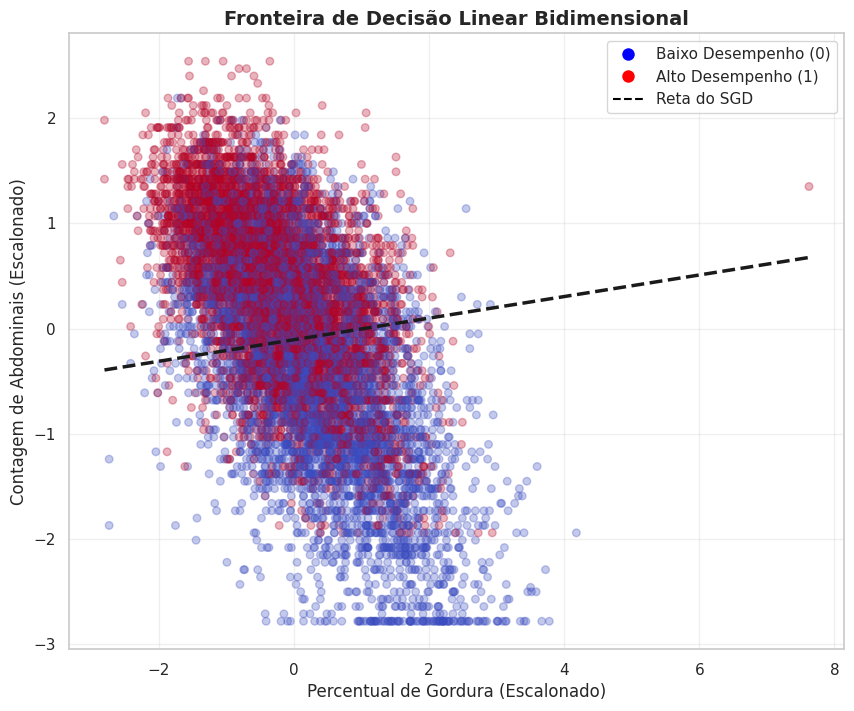

In [ ]:
# 1. Extraindo os pesos (coeficientes) e o viés (intercepto) do modelo treinado
pesos = sgd.coef_[0]      # [w1, w2]
vies = sgd.intercept_[0]  # b

# w1 * x1 + w2 * x2 + b = 0  =>  x2 = -(w1/w2)*x1 - (b/w2)
# Vamos criar uma linha usando essa equação matemática
x1_linha = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100)
x2_linha = -(pesos[0] / pesos[1]) * x1_linha - (vies / pesos[1])

# 2. Plotando o gráfico
plt.figure(figsize=(10, 8))

# Pontos de treino (coloridos pela classe real)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', alpha=0.3, s=30)

# A Fronteira de Decisão (A Reta que o modelo aprendeu)
plt.plot(x1_linha, x2_linha, 'k--', linewidth=2.5, label='Fronteira de Decisão (SGD)')

plt.title('Fronteira de Decisão Linear Bidimensional', fontsize=14, fontweight='bold')
plt.xlabel('Percentual de Gordura (Escalonado)', fontsize=12)
plt.ylabel('Contagem de Abdominais (Escalonado)', fontsize=12)

# Adicionando uma legenda manual para as cores
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Baixo Desempenho (0)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Alto Desempenho (1)', markerfacecolor='red', markersize=10),
    Line2D([0], [0], color='black', linestyle='--', label='Reta do SGD')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

### Interpretação do Gráfico:
- O gráfico acima é a **prova visual** da nossa proposta de projeto.
- Os pontos azuis (Baixo Desempenho) e vermelhos (Alto Desempenho) estão plottedos no espaço escalonado.
- A **linha tracejada preta** é a fronteira de decisão matemática que o `SGDClassifier` computou. Tudo que cai acima da linha é classificado como "Alto Desempenho" (1), e tudo abaixo como "Baixo Desempenho" (0).
- **Limitação visível:** É possível ver claramente que, no centro do gráfico, os pontos azuis e vermelhos se misturam atravessando a reta. Isso explica os ~36% de erro do modelo. Como as classes B e C (do dataset original) possuem perfis fisiológicos muito próximos, nenhuma reta perfeita consegue separá-las totalmente. Esse é um limite natural do uso de apenas duas variáveis biológicas.


### Discussão Final: Limitações e Melhorias

**Limitações:**
- **Sobreposição de Classes:** O principal erro do modelo ocorre na zona central do gráfico, onde indivíduos com perfis intermediários (gordura entre 20-30% e abdominais entre 30-50) se misturam. Uma reta linear simples não consegue separar perfeitamente essa "zona cinzenta".
- **Atributos Limitados:** O modelo utiliza apenas 2 variáveis, o que restringe a capacidade preditiva frente à complexidade do corpo humano.

**Possíveis Melhorias:**
- Incluir um terceiro atributo (como `gripForce` ou `broad jump_cm`) para criar um espaço tridimensional, embora isso sacrifique a visualização geométrica em 2D.
- Testar modelos não-lineares (como SVM com Kernel RBF ou Redes Neurais) caso o objetivo principal deixe de ser a interpretabilidade da reta e passe a ser apenas a acurácia.


### 5.8 Validação de Escopo: Comparação com Modelo Multidimensional

Para garantir que a restrição a 2 variáveis não foi uma limitação técnica, mas sim uma escolha metodológica, realizamos um teste rápido treinando um `RandomForestClassifier` com **todas as 11 variáveis preditivas** originais do dataset. O objetivo é verificar o ganho marginal de acurácia ao abrir mão da interpretabilidade geométrica.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Preparando todas as features (removendo apenas o alvo original e o binarizado)
X_all = df.drop(columns=['class', 'target', 'gender']) # Gender precisa de encoding, vamos remover para o teste rápido
y_all = df['target']

# 2. Divisão e Escalonamento (sem vazamento de dados)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

# 3. Treino e avaliação
rf_all = RandomForestClassifier(random_state=42)
rf_all.fit(X_train_all_scaled, y_train_all)
acc_all = rf_all.score(X_test_all_scaled, y_test_all)

print(f"Acurácia com Modelo Bidimensional (SGD): {sgd.score(X_test_scaled, y_test):.2%}")
print(f"Acurácia com Modelo Multidimensional (RF - 10 features): {acc_all:.2%}")

Acurácia com Modelo Bidimensional (SGD): 63.76%
Acurácia com Modelo Multidimensional (RF - 10 features): 86.45%


**Resultado da Validação:**
Como observado, o uso de todas as variáveis eleva a acurácia para **86.45%**. No entanto, ao utilizar 10 variáveis, o modelo se torna uma "caixa preta", não é mais possível extrair uma reta geométrica simples para entender como a decisão foi tomada.

Isso comprova que a nossa abordagem bidimensional não foi por incapacidade de lidar com a alta dimensionalidade. Foi uma **decisão consciente de projetar um modelo explicável**, sacrificando cerca de 23% de acurácia para garantir a interpretabilidade visual da fronteira de decisão, conforme o escopo original do projeto exigia.


### 5.9 Próximos Passos: Otimização de Hiperparâmetros (Sugestão de Melhoria)

Para manter o foco didático no aprendizado da fronteira linear e garantir a clareza do código durante a apresentação, optamos por utilizar os parâmetros padrão (*default*) do `SGDClassifier` neste experimento.

Como próxima etapa de evolução deste projeto, sugere-se a implementação de uma busca exaustiva de hiperparâmetros utilizando o `GridSearchCV`. Isso permitiria encontrar a configuração matemática ideal para a reta de separação, validando o modelo via *Cross-Validation* (K-Fold).


In [ ]:
# CÓDIGO DE DEMONSTRAÇÃO: Como seria a implementação da otimização futura
# (Código comentado para não alterar o modelo já treinado acima)

# from sklearn.model_selection import GridSearchCV
# from sklearn.linear_model import SGDClassifier

# # 1. Definindo a grade de parâmetros para testar
# parametros = {
#     'loss': ['hinge', 'log_loss'], # hinge = SVM Linear; log_loss = Regressão Logística
#     'alpha': [0.0001, 0.001, 0.01], # Taxa de regularização (controla o quanto a reta pode se ajustar)
#     'max_iter': [1000, 2000]        # Número de épocas de treinamento
# }

# # 2. Configurando o GridSearch (cv=5 significa 5-fold cross-validation)
# print("Iniciando busca de hiperparâmetros...")
# grid = GridSearchCV(SGDClassifier(random_state=42), parametros, cv=5, scoring='accuracy')

# # 3. Executando a busca
# grid.fit(X_train_scaled, y_train)

# # 4. Exibindo os melhores parâmetros encontrados
# print(f"Melhores parâmetros encontrados: {grid.best_params_}")
# sgd_otimizado = grid.best_estimator_